# Scaling analysis

In [1]:
import pandas as pd 

df_2 = pd.read_csv('logs/time_scaling/speed_2.csv')
df_2["modalities"] = "2"

df_4 = pd.read_csv('logs/time_scaling/speed_4.csv')
df_4["modalities"] = "4"

df_8 = pd.read_csv('logs/time_scaling/speed_8.csv')
df_8["modalities"] = "8"

combined = pd.concat([df_2, df_4, df_8], ignore_index=True)

In [2]:
# Add relative time (seconds since each dataframe start)
for df in (df_2, df_4, df_8):
    df["relative_time"] = df["Wall time"] - df["Wall time"].min()

# Keep combined consistent with per-modality relative time
combined["relative_time"] = (
    combined.groupby("modalities")["Wall time"]
    .transform(lambda s: s - s.min())
)

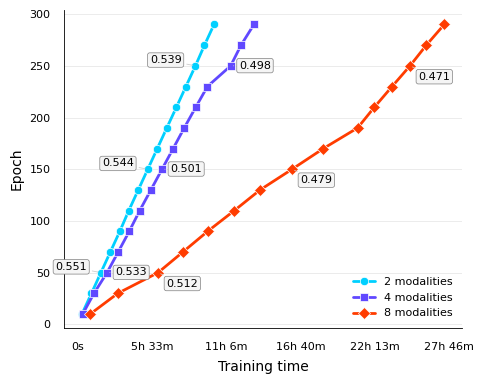

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})

SPINE_LW = 0.6
GRID_COLOR = "#ececec"
GRID_LW = 0.7
TEXT_COLOR = "black"

def human_readable_time(seconds, _):
    seconds = int(seconds)
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    if h:
        return f"{h}h {m}m" if m else f"{h}h"
    if m:
        return f"{m}m"
    return f"{s}s"



colors = {"2": "#00D0FF", "4": "#6048FF", "8": "#FF3C00"}
markers = {"2": "o", "4": "s", "8": "D"}

DATASET_SIZE = 100_000 
target_epochs = list(range(10, 310, 20))
annot_epochs = [50, 150, 250]

fig, ax = plt.subplots(figsize=(5, 4.0))

# Offset for annotations: 2 mod on left of curve, 4 and 8 on right
annot_offsets = {"2": (-10, 2), "4": (6, -2), "8": (6, -10)}
annot_ha = {"2": "right", "4": "left", "8": "left"}

annot_bbox = dict(boxstyle="round,pad=0.2", facecolor="#f5f5f5", edgecolor="grey", linewidth=0.5)

for mod_label, df_mod in [("2", df_2), ("4", df_4), ("8", df_8)]:
    df_mod = df_mod.copy()
    df_mod["epoch"] = (df_mod["Step"] * 128 / DATASET_SIZE).round().astype(int)

    times, epochs = [], []
    for ep in target_epochs:
        matched = df_mod[df_mod["epoch"] >= ep]
        if len(matched) == 0:
            break
        r = matched.iloc[0]
        times.append(r["relative_time"])
        epochs.append(ep)

    ax.plot(
        times, epochs,
        color=colors[mod_label], linewidth=2, alpha=1,
        marker=markers[mod_label], markersize=6,
        markerfacecolor=colors[mod_label],
        markeredgecolor="white", markeredgewidth=0.5,
        label=f"{mod_label} modalities",
        solid_capstyle="round",
    )

    for ep_ann in annot_epochs:
        matched = df_mod[df_mod["epoch"] >= ep_ann]
        if len(matched) > 0:
            r = matched.iloc[0]
            t = r["relative_time"]
            mae_val = r["Value"]
            ax.annotate(
                f"{mae_val:.3f}",
                (t, ep_ann),
                textcoords="offset points",
                xytext=annot_offsets[mod_label],
                ha=annot_ha[mod_label],
                fontsize=8,
                color="black",
                bbox=annot_bbox,
                arrowprops=dict(arrowstyle="-", color="#cccccc", lw=0.6),
            )

# Draw faint horizontal lines at annotated epochs
for ep_ann in annot_epochs:
    ax.axhline(ep_ann, color="#e0e0e0", linewidth=0.6, zorder=0)

ax.xaxis.set_major_formatter(FuncFormatter(human_readable_time))
ax.set_xlabel("Training time", fontsize=10, color=TEXT_COLOR, labelpad=6)
ax.set_ylabel("Epoch", fontsize=10, color=TEXT_COLOR, labelpad=4)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=GRID_LW)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(TEXT_COLOR)
    ax.spines[side].set_linewidth(SPINE_LW)

ax.legend(fontsize=8, frameon=False, labelcolor=TEXT_COLOR, loc="lower right")
ax.tick_params(axis="both", colors=TEXT_COLOR, labelsize=8)

fig.tight_layout()
plt.savefig("figures/scaling_pareto.png", dpi=300, bbox_inches="tight")
plt.show()
